# <center>Mathematical Foundations of Analytics 
## <center>CS660 – (CRN# 22921)
## <center>By: Prof. Thassos Sarbanes
## <center>Spring 2025 - Project #2
<center>Ran Roffe <br>Nipun Ranchhod Navadia

In [3]:
# importing libraries
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.linalg import null_space
from sklearn.preprocessing import normalize
from numpy.linalg import linalg as LA
from numpy.linalg import svd
from sklearn.decomposition import PCA
from scipy.linalg import null_space

## 1) Computation of Eigenvalues, Eigenvectors of a Matrix:
Compare your code’s runtime vs Python’s NumPy/eig: 

https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

### Eigenvalues & Eigenvectors

An eigenvector of a square matrix $A$ with dimension $n×n$ is a non-zero vector $v$ such that, when $v$ is multiplied on the left by $A$, it yields a constant multiple of $v$. That is
$$Av=λv
$$
The number $λ$ is called the eigenvalue of $A$ corresponding to the eigenvector $v$.
To find the eigenvalues, we start by rearranging this equation to get
$$ Av − λv = 0$$
$$(A − λI)v	= 0
$$


where $I$ is the $n×n$ identity matrix. For the left-hand side of this equation to equal zero, either $v=0$ or $|A−λI|=0$. We cannot have $v=0$, because it gives us no information, so we must have:

$$|A−λI|=0$$

Evaluating the determinant of $A−λI$ gives the characteristic polynomial of $A$ in terms of $λ$. Setting this polynomial equal to zero gives the characteristic equation. The eigenvalues of $A$ are the solutions of this equation.


### Computation of Eigenvalues - null space

In [10]:
def eigenvalues(A):
    """Calculating the eigenvalues.

    Args:
        A (np.ndarray): The matrix to to compute eigenvalues.

    Returns:
        eigvals (np.ndarray): The matrix having eigenvalues in descending order.
    """
    # computing coefficients of  polynomial
    char_poly_coeffs = np.poly(A)  
    
    # solve polynomial for roots (eigenvalues)
    eigvals = np.roots(char_poly_coeffs) 

    # returning the eigenvalues in descending order
    return np.sort(eigvals)[::-1]  

### Computation of Eigenvectors - null space

In [12]:
def eigenvectors(A):
    """Calculating the eigenvectors.

    Args:
        A (np.ndarray): The matrix to to compute eigenvectors.

    Returns:
        eigvals (np.ndarray): The matrix having eigenvalues in descending order.
        eigvecs (np.ndarray): The matrix having eigenvectors in descending order.
    """
    eigvals = eigenvalues(A)
    eigvecs = []

    # for loop to compute A-lambda.I with computing eigenvectors with null space method.
    for lamda in eigvals:
        M = A - lamda * np.eye(A.shape[0])
        v = null_space(M, rcond=1e-10)

        if v.shape[1] > 0:
            # normalizing each eigenvector
            
            v = normalize(v, axis=0) 
            # taking the first basis vector
            eigvecs.append(v[:, 0])  
        else:
            eigvecs.append(np.zeros(A.shape[0]))
    eigvecs = np.column_stack(eigvecs)  

    return eigvals, eigvecs  

#### Example Usage:

In [17]:
A = np.array([[0, 1, 1],
              [2**0.5, 2, 0],
              [0, 1, 1]])

# manually computated eigenvalues and vectors
eigvals_manual, eigvecs_manual = eigenvectors(A)

# NumPy computation for result comparison <using agrsort to get the results in same order/matrix> 
eigvals_np, eigvecs_np = np.linalg.eig(A)
sort_idx = np.argsort(eigvals_np)[::-1]
eigvals_np_sorted = eigvals_np[sort_idx]
eigvecs_np_sorted = eigvecs_np[:, sort_idx]

# ensuring eigenvectors have consistent signs
for i in range(eigvecs_manual.shape[1]):
    if np.dot(eigvecs_manual[:, i], eigvecs_np_sorted[:, i]) < 0:
        eigvecs_manual[:, i] *= -1

print("Manual Eigenvalues:\n", eigvals_manual)
print("\nManual Eigenvectors:\n", eigvecs_manual)
print("\nNumPy Eigenvalues:\n", eigvals_np_sorted)
print("\nNumPy Eigenvectors:\n", eigvecs_np_sorted)

Manual Eigenvalues:
 [ 2.79004402e+00  2.09955984e-01 -1.85180364e-16]

Manual Eigenvectors:
 [[-0.43834959  0.61731105  0.70710678]
 [-0.78466507 -0.4877029  -0.5       ]
 [-0.43834959  0.61731105  0.5       ]]

NumPy Eigenvalues:
 [ 2.79004402e+00  2.09955984e-01 -1.85180364e-16]

NumPy Eigenvectors:
 [[-0.43834959  0.61731105  0.70710678]
 [-0.78466507 -0.4877029  -0.5       ]
 [-0.43834959  0.61731105  0.5       ]]


#### Check Residuals
For a given square matrix $A$, an eigenvalue $λ$ and a corresponding eigenvector $v$, the residual is calculated as:

$$r=Av-λv$$
where:

* $(Av)$ represents the matrix-vector multiplication.

* $(λv)$ is the scalar multiplication of the eigenvalue with the eigenvector.

* $(r)$ is the residual vector, which should ideally be close to zero.

To quantify the residual, we compute its norm:
$$||r||=||Av-λv||$$
$A$ small norm value indicates that $(λ,v)$ is a valid approximation of an eigenpair.

In [20]:
for i in range(len(eigvals_manual)):
    v = eigvecs_manual[:, i]
    lambda_v = eigvals_manual[i]
    residual = np.linalg.norm(np.dot(A,v) - lambda_v * v)
    print(f"Eigenvector {i} residual: {residual}")

Eigenvector 0 residual: 3.155846784686366e-15
Eigenvector 1 residual: 5.412337245047638e-16
Eigenvector 2 residual: 1.5327356554118197e-16


## 2) Computation of Principal Components of a Matrix:
Compare your code’s runtime vs Python’s NumPy/pca: 

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

### Prinipal Component Analysis

Principal component analysis, or PCA, reduces the number of dimensions in large datasets to principal components that retain most of the original information. It does this by transforming potentially correlated variables into a smaller set of variables, called principal components.

### Principle Components

Principal components are new variables that are constructed as linear combinations or mixtures of the initial variables. These combinations are done in such a way that the new variables (i.e., principal components) are uncorrelated and most of the information within the initial variables is squeezed or compressed into the first components

The steps we are going to preform are:
* Standardize / Normalize data (mean centering)
* Compute the covariance matrix
* Compute the eigenvectors and eigenvalues of the covariance matrix to identify the PCs
* Compute the explained variance and select N PCs
* Create feature vector with all PCs, sorted by their importance

Example matrix:

In [24]:
# example matrix
matrix = np.array([[2, 4, 1], [3, 7, 2], [5, 10, 4]])
print(f"The matrix is:\n{matrix}\n")

The matrix is:
[[ 2  4  1]
 [ 3  7  2]
 [ 5 10  4]]



### Step 1: Mean Centering the Data (Standardize / Normalize) 

Since PCA can bias towards specific features, it is important to evaluate whether normalization of data is needed. Data should reflect a normal distribution with a mean of zero and a standard deviation of one.

In this step, the mean values of the variables are calculated and subtracted from the original dataset so that each variable contributes equally to the analysis. This value is then divided by the standard deviation for each variable so that all variables use the same scale.

The data matrix \( X \) is centered by subtracting the mean of each feature:
$$
X_{\text{centered}} = X - \mu
$$
where \( $\mu$ \) is the mean of each column (feature).  


*NOTES*:
Normalization is recommended when:
* The features have different scales (e.g., one column represents height and another represents weight).
* The dataset has features with very different variances, which could make PCA biased toward high-variance features.

Normalization is not recommended when:
* The variance itself is meaningful (for example: analyzing financial data where large values inherently carry more weight).

In [27]:
def center_data(matrix: np.ndarray, standardize: bool=False, normalize: bool=False, to_print: bool=True) -> np.ndarray:
    
    """center the data in a matrix by subtracting the mean vector.

    Args:
        matrix (np.ndarray): The matrix to center.
        standardize (bool): Whether to standardize the data.
        normalize (bool): Whether to normalize the data.
        to_print (bool): Whether to print the the process.

    Returns:
        np.ndarray: The centered matrix.
    """

    # if standadization is needed
    if standardize:
        scaler = StandardScaler()
        matrix = scaler.fit_transform(matrix)
        if to_print: 
            print(f"The standardized matrix is:\n{matrix}\n")
    
    # if normalization is needed
    if normalize:
        scaler = MinMaxScaler()
        matrix = scaler.fit_transform(matrix)
        if to_print: 
            print(f"The normalized matrix is:\n{matrix}\n")        
    
    # compute the mean of each column
    mean = np.mean(matrix, axis=0)

    if to_print: 
        print(f"The mean vector is:\n{mean}\n")
    
    # center the data
    centered = matrix - mean
    if to_print: 
        print(f"The centered matrix is:\n{centered}\n")

    return centered

In [29]:
# print the original matrix
print(f"The original matrix is:\n{matrix}\n")

# center the data
centered = center_data(matrix)

The original matrix is:
[[ 2  4  1]
 [ 3  7  2]
 [ 5 10  4]]

The mean vector is:
[3.33333333 7.         2.33333333]

The centered matrix is:
[[-1.33333333 -3.         -1.33333333]
 [-0.33333333  0.         -0.33333333]
 [ 1.66666667  3.          1.66666667]]



### Step 2: Covariance Matrix Computation

The covariance matrix is an essential statistical tool that quantifies the relationships between different features in a dataset.

The covariance matrix is computed as:
$$
C = \frac{1}{n-1} X^T X
$$

where:

* $(C)$ is the covariance matrix.

* $(X)$ is the data matrix, where each row represents an observation and each column represents a feature.

* $(X^T)$ is the transpose of $X$.

* $(n)$ is the number of observations (samples).

* $(\frac{1}{n-1})$ is a normalization factor (Bessel’s correction) that ensures an unbiased estimate of covariance.

The sign of the variables in the matrix tells us whether combinations are correlated:

* Positive (the variables are correlated and increase or decrease at the same time)

* Negative (the variables are not correlated, meaning that one decreases while the other increases)

* Zero (the variables are not related to each other)

In [32]:
def cov_matrix(matrix: np.ndarray, to_print: bool=True) -> np.ndarray:
    """compute the covariance matrix of a matrix.

    Args:
        matrix (np.ndarray): The matrix to compute the covariance matrix for.
        to_print (bool): Whether to print the the process.

    Returns:
        cov_matrix (np.ndarray): The covariance matrix.
    """
    # number of features(columns)
    n = matrix.shape[1]

    # compute the covariance matrix using the formula: cov(X) = (X.T * X) / (n - 1)
    cov_matrix = np.dot(centered.T, centered) / (n - 1)

    if to_print:
        print(f"The covariance matrix is:\n{cov_matrix}\n")
    
    return cov_matrix

In [34]:
cov = cov_matrix(matrix)

The covariance matrix is:
[[2.33333333 4.5        2.33333333]
 [4.5        9.         4.5       ]
 [2.33333333 4.5        2.33333333]]



### Step 3: Computing Eigenvalues and Eigenvectors for Covariance matrix
Solve the eigenvalue problem:
$$
C v = \lambda v
$$
where:
- \( $C$ \) is the covariance matrix
- \( $\lambda$ \) are the eigenvalues
- \( $v$ \) are the corresponding eigenvectors

In [37]:
eigvals, eigenvecs = eigenvectors(cov)

eigvals, eigenvecs

(array([1.35560147e+01, 1.10651990e-01, 9.14608560e-17]),
 array([[-4.11615100e-01, -5.74954789e-01, -7.07106781e-01],
        [-8.13108860e-01,  5.82111657e-01, -3.05159703e-15],
        [-4.11615100e-01, -5.74954789e-01,  7.07106781e-01]]))

## Step 4: Compute Explained Variance and Select N PCs

Here, we decide which components to keep and those to discard. Components with low eigenvalues typically will not be as significant. Scree plots usually plot the proportion of total variance explained and the cumulative proportion of variance. These metrics help one to determine the optimal number of components to retain. The point at which the Y axis of eigenvalues or total variance explained creates an "elbow" will generally indicate how many PCA components that we want to include.

The explained variance ratio for each principal component is given by:
$$
\text{explained variance} = \frac{\lambda_i}{\sum \lambda}
$$

Choose the top \(k\) eigenvectors corresponding to the largest \(k\) eigenvalues to form the projection matrix \(W\):
$$
W = [v_1, v_2, \dots, v_k]
$$

In [40]:
def sort_eigenvalues(eigvals: np.ndarray, eigenvecs: np.ndarray,
                     k_pcs: int, to_print: bool=True) -> tuple[np.ndarray, np.ndarray]:
    """Sort the eigenvalues and eigenvectors in descending order.

    Args:
        eigvals (np.ndarray): The eigenvalues to sort.
        eigenvecs (np.ndarray): The eigenvectors to sort.
        k_pcs (int): The number of principal components to keep.
        to_print (bool): Whether to print the the process.

    Returns:
        top_k_sorted_eigvals, top_k_sorted_eigenvecs - tuple[np.ndarray, np.ndarray]: The sorted eigenvalues and eigenvectors.
    """
    
    # sorting the eigenvalues in descending order
    sorted_indices = np.argsort(-eigvals)
    sorted_eigvals = eigvals[sorted_indices]
    sorted_eigenvecs = eigenvecs[:,sorted_indices]

    if to_print:
        print(f"The sorted eigenvalues are:\n{sorted_eigvals}\n")
        print(f"The sorted eigenvectors are:\n{sorted_eigenvecs}\n")
    
    # return top k eigenvalues and eigenvectors
    top_k_sorted_eigvals = sorted_eigvals[:k_pcs]
    top_k_sorted_eigenvecs = sorted_eigenvecs[:, :k_pcs]

    return top_k_sorted_eigvals, top_k_sorted_eigenvecs

In [46]:
k=2
top_k_sorted_eigenvalues, top_k_sorted_eigenvectors = sort_eigenvalues(eigvals, eigenvecs, k)
print(f"The top {k} sorted eigenvalues are:\n{top_k_sorted_eigenvalues}\n")
print(f"The top {k} sorted eigenvectors are:\n{top_k_sorted_eigenvectors}\n")

The sorted eigenvalues are:
[1.35560147e+01 1.10651990e-01 9.14608560e-17]

The sorted eigenvectors are:
[[-4.11615100e-01 -5.74954789e-01 -7.07106781e-01]
 [-8.13108860e-01  5.82111657e-01 -3.05159703e-15]
 [-4.11615100e-01 -5.74954789e-01  7.07106781e-01]]

The top 2 sorted eigenvalues are:
[13.55601468  0.11065199]

The top 2 sorted eigenvectors are:
[[-0.4116151  -0.57495479]
 [-0.81310886  0.58211166]
 [-0.4116151  -0.57495479]]



### Step 5: Feature Vector with PCs

We transform data into the new coordinate system defined by the principal components. That is, the feature vector created from the eigenvectors of the covariance matrix projects the data onto the new axes defined by the principal components. This creates new data, capturing most of the information but with fewer dimensions than the original dataset.

Transform the original data using the selected principal components:
$$
X_{\text{transformed}} = X W
$$

Where $W$ is the top k eigenvectors matrix.

In [49]:
# creating feature vector with all PCs, sorted by their importance
feature_vector = np.dot(centered, top_k_sorted_eigenvectors)
print(f"The feature vector is:\n{feature_vector}\n")
print(f"The shape of the feature vector is:\n{feature_vector.shape}\n")
print(f"The first 5 elements of the feature vector are:\n{feature_vector[:5]}\n")
print(f"The last 5 elements of the feature vector are:\n{feature_vector[-5:]}\n")

The feature vector is:
[[ 3.53696685 -0.2131222 ]
 [ 0.27441007  0.38330319]
 [-3.81137691 -0.17018099]]

The shape of the feature vector is:
(3, 2)

The first 5 elements of the feature vector are:
[[ 3.53696685 -0.2131222 ]
 [ 0.27441007  0.38330319]
 [-3.81137691 -0.17018099]]

The last 5 elements of the feature vector are:
[[ 3.53696685 -0.2131222 ]
 [ 0.27441007  0.38330319]
 [-3.81137691 -0.17018099]]



In [53]:
def principal_component_analysis(matrix: np.ndarray, k_pcs: int, standardize: bool=True, 
                                 normalize: bool=True, to_print: bool=True) -> np.ndarray:
    """Compting PCA for a matrix.

    Args:
        matrix (np.ndarray): The matrix to perform PCA on.
        k_pcs (int): The number of principal components to keep.
        standardize (bool): Whether to standardize the data.
        normalize (bool): Whether to normalize the data.
        to_print (bool): Whether to print the the process.

    Returns:
        feature_vector (np.ndarray): The feature vector.
    """
    # center the data
    centered = center_data(matrix, standardize=standardize, normalize=normalize, to_print=to_print)

    # compute the covariance matrix
    cov = cov_matrix(centered, to_print=to_print)

    # compute the eigenvalues and eigenvectors
    eigvals, eigenvecs = eigenvectors(cov)

    # sort the eigenvalues and eigenvectors in descending order
    _top_k_sorted_eigenvalues, top_k_sorted_eigenvectors = sort_eigenvalues(eigvals, eigenvecs, k_pcs, to_print=to_print)

    # create feature vector with all PCs, sorted by their importance
    feature_vector = np.dot(centered, top_k_sorted_eigenvectors)

    return feature_vector

## 3) Computation of Singular Values of a Matrix (SVD):
Compare your code’s runtime vs Python’s NumPy/svd:

https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html

### Singular Value Decomposition
The singular value decomposition of a matrix $A$ is the factorization of $A$ into the product of three matrices $A= UΣV^T$ where the columns of $U$ and $V$ are orthonormal and the matrix $Σ$ is diagonal with positive real entries.

SVD decomposes any $m \times n$ matrix A into three matrices: $A=U \Sigma V^T$

* $U : $ an $m \times m$ matrix that contains the eigenvectors of $AA^T$.
* $\Sigma : $ $m \times n$ diagonal matrix that contains the singular values which are square roots of common non-zero eigenvalues of $A^TA$ and $AA^T$ in descending order.
* $V: $ an $n \times n$ matrix that contains the eigenvectors of $A^TA$.

Example matrics:

In [62]:
# # example 1: matrix 3x3
# mat1 = np.array([[0, 1, 1], [np.sqrt(2), 2, 0], [0, 1, 1]])

# # example 2: matrix 4x3
# mat2 = np.array([[0, 1, 1], [np.sqrt(2), 2, 0], [0, 1, 1], [0, 1, 1]])

# print (f"The first matrix is:\n{mat1}\n")
# print (f"The second matrix is:\n{mat2}\n")

In [66]:
def eigenvalues(A: np.ndarray) -> np.ndarray:
    """Calculate eigenvalues of a square matrix A using the QR algorithm.
    
    Args:
        A (numpy.ndarray): Square matrix
    
    Returns:
        numpy.ndarray: Array of eigenvalues
    """
    # checking if A is a square matrix
    n, m = A.shape
    if n != m:
        raise ValueError("Matrix must be square")
    
    # creating a copy to avoid modifying the original
    A_copy = A.copy()
    
    # apply the QR algorithm to find eigenvalues
    max_iter = 100
    tol = 1e-8
    
    for _ in range(max_iter):
        # QR decomposition
        Q, R = np.linalg.qr(A_copy)
        
        # create new matrix A = RQ
        A_new = np.dot(R,Q)
        
        # checking convergence (when off-diagonal elements are close to zero)
        if np.sum(np.abs(np.tril(A_new, -1))) < tol:
            break
            
        A_copy = A_new
    
    # extract eigenvalues from the diagonal
    return np.diag(A_copy)

def qreigenvectors(A, eigenvals=None):
    """Calculate eigenvectors of a square matrix A.
    
    Args:
        A - (numpy.ndarray): Square matrix
        eigenvals - (numpy.ndarray, optional): Eigenvalues if already computed
    
    Returns:
        numpy.ndarray: Matrix of eigenvectors (by column)
    """
    # checking if A is a square matrix
    n, m = A.shape
    if n != m:
        raise ValueError("Matrix must be square")
    
    # getting eigenvalues if not computed
    if eigenvals is None:
        eigenvals = eigenvalues(A)
    
    # create storage for eigenvectors
    eigenvecs = np.zeros((n, n))
    
    # for each eigenvalue, finding the corresponding eigenvector
    for i, eigenval in enumerate(eigenvals):
        # creating matrix (A - λI)
        A_lambda = A - eigenval * np.eye(n)
        
        # using power iteration to find the eigenvector in the null space
        v = np.random.rand(n)
        v = v / np.linalg.norm(v)
        
        # computing inverse iteration
        for _ in range(50):
            # adding small value to diagonal for numerical stability
            A_mod = A_lambda + 1e-10 * np.eye(n)
            
            # solving the system (A - λI)w = v, this finds vectors in the null space of (A - λI)
            w = np.linalg.solve(A_mod, v)
            
            # normalizing
            w = w / np.linalg.norm(w)
            
            # checking for convergence
            if np.linalg.norm(w - v) < 1e-10 or np.linalg.norm(w + v) < 1e-10:
                break
                
            v = w
        
        eigenvecs[:, i] = v
    
    return eigenvecs

In [68]:
def svd_decomposition(A):
    """Perform Singular Value Decomposition (SVD) manually.
    A = U Σ V^T
    
    Args:
        A (np.ndarray): Input matrix to decompose.
    
    Returns:
        U (np.ndarray), Sigma (np.ndarray), V (np.ndarray): SVD result
    """
    
    # calculating V as A^T A and U as A A^T
    AtA = np.dot(A.T,A) 
    AAt = np.dot(A,A.T) 
    
    # computing eigenvalues and eigenvectors
    eigenvals_AtA = eigenvalues(AtA)
    eigenvals_AAt = eigenvalues(AAt)
    
    # sorting eigenvalues and getting indices
    sorted_indices_AtA = np.argsort(eigenvals_AtA)[::-1]
    sorted_indices_AAt = np.argsort(eigenvals_AAt)[::-1]
    
    # getting sorted eigenvalues
    eigenvals_AtA_sorted = eigenvals_AtA[sorted_indices_AtA]
    eigenvals_AAt_sorted = eigenvals_AAt[sorted_indices_AAt]
    
    # computing eigenvectors
    V = qreigenvectors(AtA)
    U = qreigenvectors(AAt)
    
    # sorting eigenvectors
    V = V[:, sorted_indices_AtA]
    U = U[:, sorted_indices_AAt]
    
    # computing singular values (square root of eigenvalues of A^T A)
    singular_values = np.sqrt(np.abs(eigenvals_AtA_sorted))
    
    # creating Sigma matrix
    m, n = A.shape
    Sigma = np.zeros((m, n))
    min_dim = min(m, n)
    for i in range(min_dim):
        Sigma[i, i] = singular_values[i]
    
    # computing the sign of U columns to ensure A = U Σ V^T
    for i in range(min_dim):
        
        # calculating dot product of A and v_i
        A_vi = np.dot(A, V[:, i])
        
        # calculating σ_i * u_i
        sigma_i_ui = singular_values[i] * U[:, i]
        
        # if dot product is negative then changing the sign of u_i
        if np.dot(A_vi, sigma_i_ui) < 0:
            U[:, i] = -U[:, i]
    
    return U, Sigma, V

#### Example usage:

In [71]:
A = np.array([[0., 1., 1.],
              [np.sqrt(2), 2., 0.],
              [0., 1., 1.]])

U, Sigma, V = svd_decomposition(A)

# printing the results
print("U Matrix:\n", U)
print("\nSigma Matrix:\n", Sigma)
print("\nV Matrix:\n", V)

# reconstructing the original matrix
reconstructed = np.dot(np.dot(U,Sigma),V.T)
print("\nOriginal Matrix:\n", A)
print("\nReconstructed Matrix:\n", reconstructed)

U Matrix:
 [[ 4.08248290e-01  5.77350269e-01 -7.07106781e-01]
 [ 8.16496581e-01 -5.77350269e-01  2.03018913e-11]
 [ 4.08248290e-01  5.77350269e-01  7.07106781e-01]]

Sigma Matrix:
 [[2.82842712e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.41421356e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.75548125e-08]]

V Matrix:
 [[ 4.08248290e-01 -5.77350269e-01  7.07106781e-01]
 [ 8.66025404e-01  3.27528776e-11 -5.00000000e-01]
 [ 2.88675135e-01  8.16496581e-01  5.00000000e-01]]

Original Matrix:
 [[0.         1.         1.        ]
 [1.41421356 2.         0.        ]
 [0.         1.         1.        ]]

Reconstructed Matrix:
 [[-8.79579659e-09  1.00000001e+00  9.99999994e-01]
 [ 1.41421356e+00  2.00000000e+00 -6.72565433e-12]
 [ 8.76124507e-09  9.99999994e-01  1.00000001e+00]]


### 4) Runtime Comparison

In [74]:
# reference matrix for computation for comparison "A":
A=np.array([[0,1,1], [(2**0.5),2,0], [0,1,1]])

#### I. Eigenvalues & Eigenvecotrs

In [77]:
%%time
print("Runtime of numpy's Eigenvectors:")
np_eigenvalues, np_eigevectors = LA.eig(A)

print(f"The eigenvalues are:\n{np_eigenvalues}\n")
print(f"The eigenvectors are:\n{np_eigevectors}\n")


Runtime of numpy's Eigenvectors:
The eigenvalues are:
[ 2.79004402e+00 -1.85180364e-16  2.09955984e-01]

The eigenvectors are:
[[-0.43834959  0.70710678  0.61731105]
 [-0.78466507 -0.5        -0.4877029 ]
 [-0.43834959  0.5         0.61731105]]

CPU times: user 714 μs, sys: 11 μs, total: 725 μs
Wall time: 727 μs


#### II. PCA

In [80]:
%%time
print("Runtime of sklearn's PCA:")
pca = PCA()
pca.fit(A)
print(pca.components_)

Runtime of sklearn's PCA:
[[ 0.70710678  0.5        -0.5       ]
 [-0.55857406  0.82855543  0.03861242]
 [ 0.43358393  0.25198393  0.86516419]]
CPU times: user 2.28 ms, sys: 1.67 ms, total: 3.96 ms
Wall time: 3.65 ms


In [82]:
%%time
print("Runtime of manual PCA:")
principal_component_analysis(A, k_pcs=2)

Runtime of manual PCA:
The standardized matrix is:
[[-0.70710678 -0.70710678  0.70710678]
 [ 1.41421356  1.41421356 -1.41421356]
 [-0.70710678 -0.70710678  0.70710678]]

The normalized matrix is:
[[0. 0. 1.]
 [1. 1. 0.]
 [0. 0. 1.]]

The mean vector is:
[0.33333333 0.33333333 0.66666667]

The centered matrix is:
[[-0.33333333 -0.33333333  0.33333333]
 [ 0.66666667  0.66666667 -0.66666667]
 [-0.33333333 -0.33333333  0.33333333]]

The covariance matrix is:
[[2.33333333 4.5        2.33333333]
 [4.5        9.         4.5       ]
 [2.33333333 4.5        2.33333333]]

The sorted eigenvalues are:
[1.35560147e+01 1.10651990e-01 6.19787942e-16]

The sorted eigenvectors are:
[[ 4.11615100e-01 -5.74954789e-01  7.07106781e-01]
 [ 8.13108860e-01  5.82111657e-01 -2.92824268e-15]
 [ 4.11615100e-01 -5.74954789e-01 -7.07106781e-01]]

CPU times: user 4.07 ms, sys: 1.23 ms, total: 5.3 ms
Wall time: 4.71 ms


array([[-0.27103629, -0.19403722],
       [ 0.54207257,  0.38807444],
       [-0.27103629, -0.19403722]])

#### III. SVD

In [85]:
%%time
print("Runtime of numpy's SVD:")
u, s, v = svd(A)
np.dot(u, np.dot(np.diag(s), v.T))

Runtime of numpy's SVD:
CPU times: user 601 μs, sys: 119 μs, total: 720 μs
Wall time: 699 μs


array([[-0.23570226,  0.66666667,  1.22474487],
       [ 1.64991582,  1.33333333,  1.22474487],
       [-0.23570226,  0.66666667,  1.22474487]])

In [87]:
%%time
print("Runtime of my SVD:")
U, Sigma, V = svd_decomposition(A)
np.dot(np.dot(U, Sigma), V.T)

Runtime of my SVD:
CPU times: user 4.12 ms, sys: 3.33 ms, total: 7.45 ms
Wall time: 6.36 ms


array([[ 8.78437691e-09,  9.99999994e-01,  1.00000001e+00],
       [ 1.41421356e+00,  2.00000000e+00, -5.88531139e-12],
       [-8.77477508e-09,  1.00000001e+00,  9.99999994e-01]])

In [91]:
""" optional """

' optional '

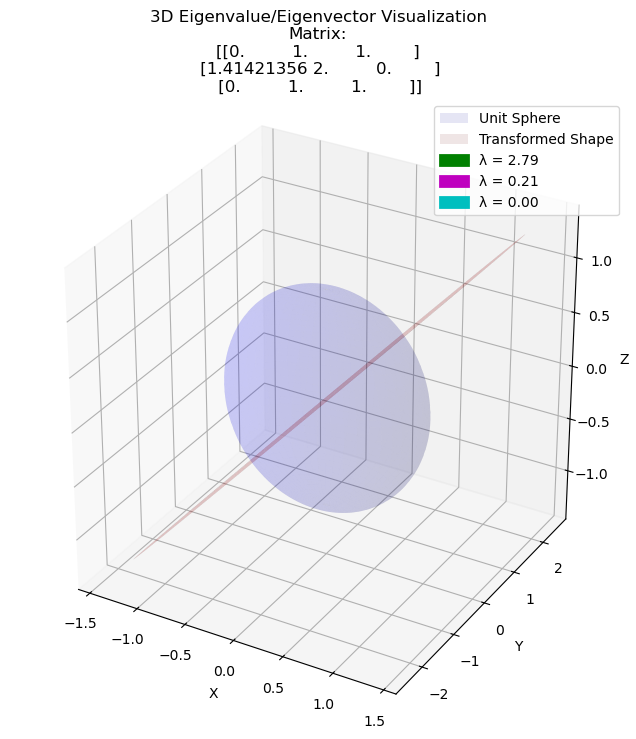

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# Custom 3D arrow class for eigenvectors
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)

# Create a 3x3 matrix (modify this to test different matrices)
A = np.array([[0,1,1], [(2**0.5),2,0], [0,1,1]])

# Compute eigenvalues and eigenvectors
eigenvalu, eigenvector = eigenvectors(A)

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Generate unit sphere points
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot unit sphere (original space)
ax.plot_surface(x, y, z, color='b', alpha=0.1, label='Unit Sphere')

# Transform sphere points with matrix A
x_t = A[0,0]*x + A[0,1]*y + A[0,2]*z
y_t = A[1,0]*x + A[1,1]*y + A[1,2]*z
z_t = A[2,0]*x + A[2,1]*y + A[2,2]*z

# Plot transformed ellipsoid
ax.plot_surface(x_t, y_t, z_t, color='r', alpha=0.1, label='Transformed Shape')

# Plot eigenvectors scaled by eigenvalues
colors = ['g', 'm', 'c']
for i in range(3):
    # Scale eigenvector by eigenvalue magnitude
    vec = eigenvalu[i] * eigenvector[:,i]
    
    # Create arrow
    arrow = Arrow3D([0, vec[0]], [0, vec[1]], [0, vec[2]], 
                    mutation_scale=20, lw=2, arrowstyle="-|>", 
                    color=colors[i], label=f'λ = {eigenvalu[i]:.2f}')
    ax.add_artist(arrow)

# Set plot properties
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Eigenvalue/Eigenvector Visualization\n'
             f'Matrix:\n{A}')
ax.legend()
ax.set_box_aspect([1,1,1])  # Equal aspect ratio
plt.show()